In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

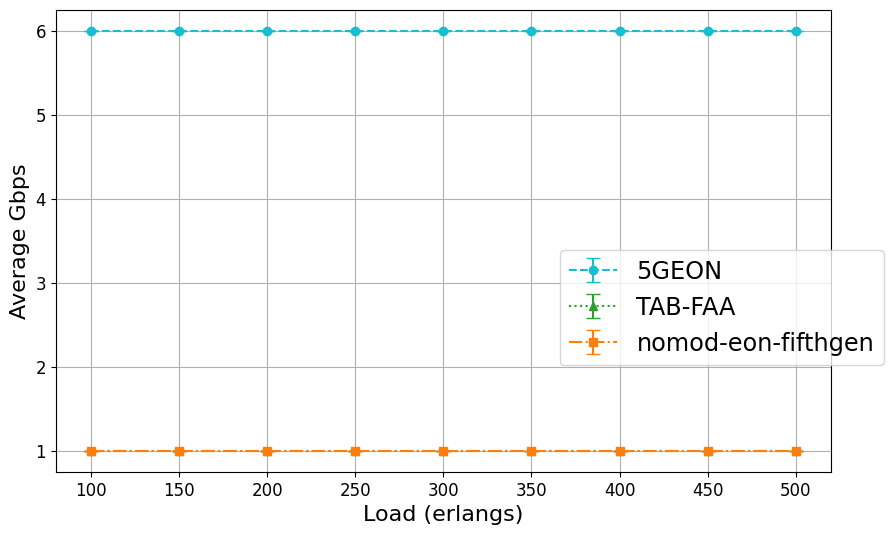

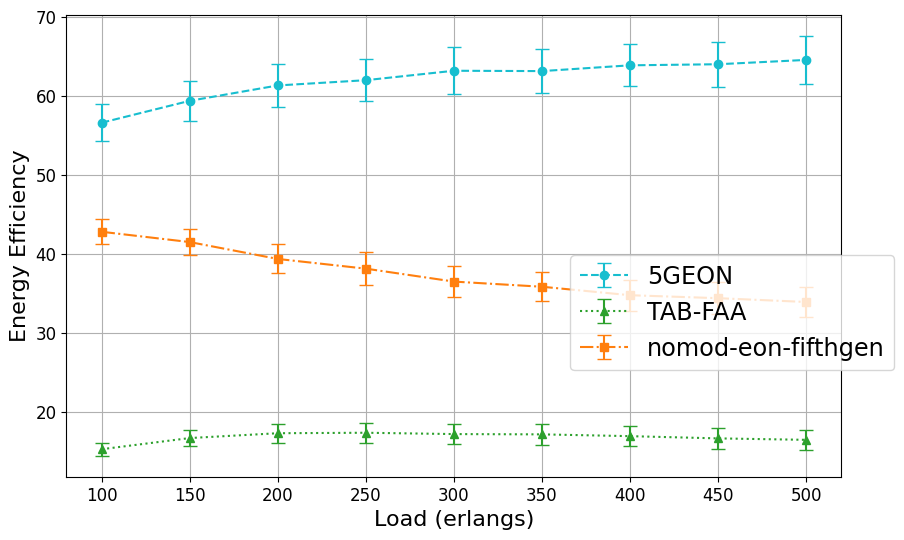

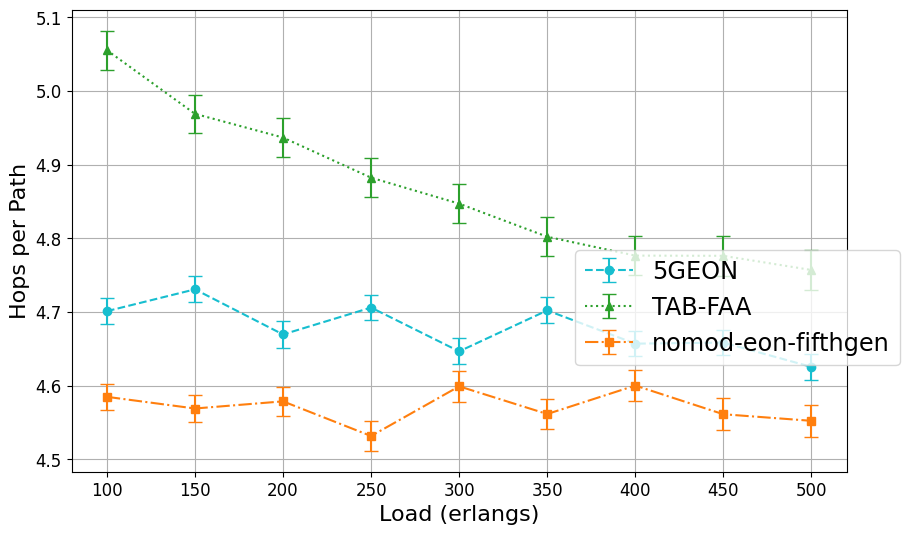

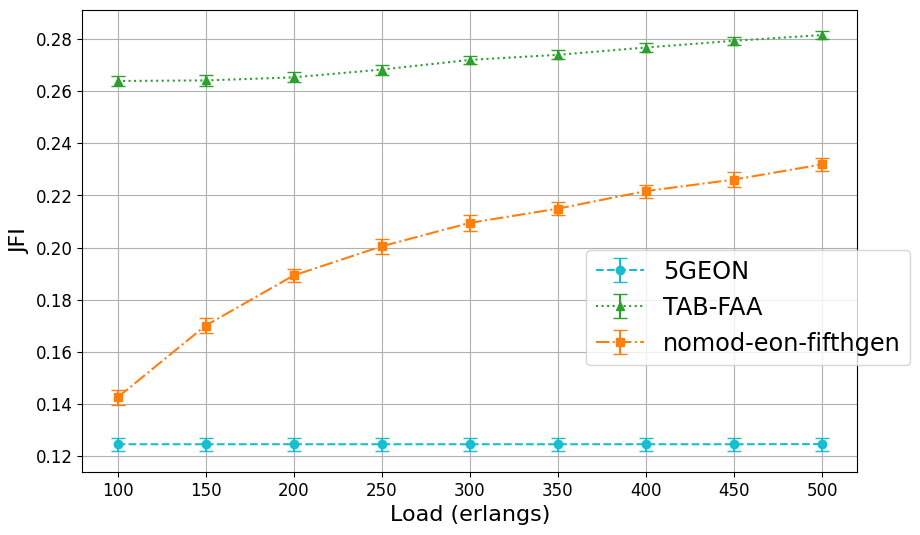

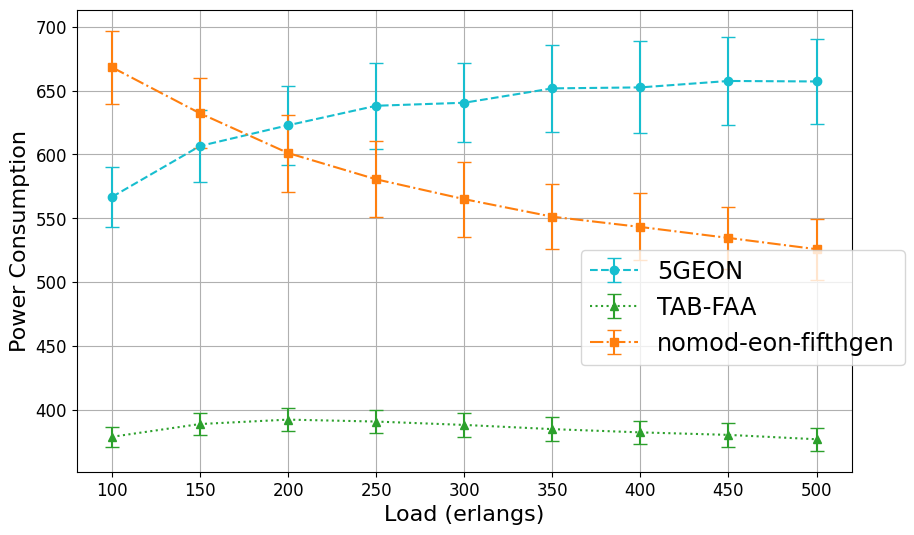

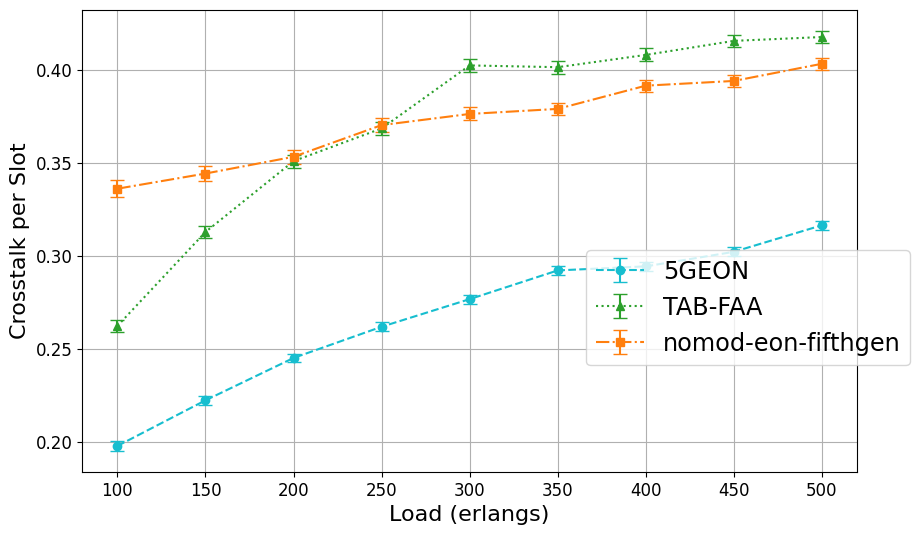

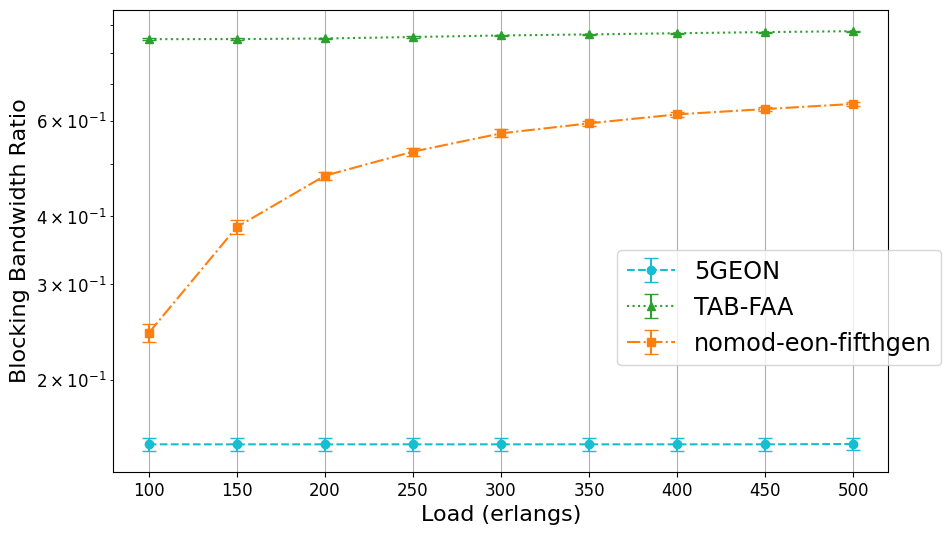

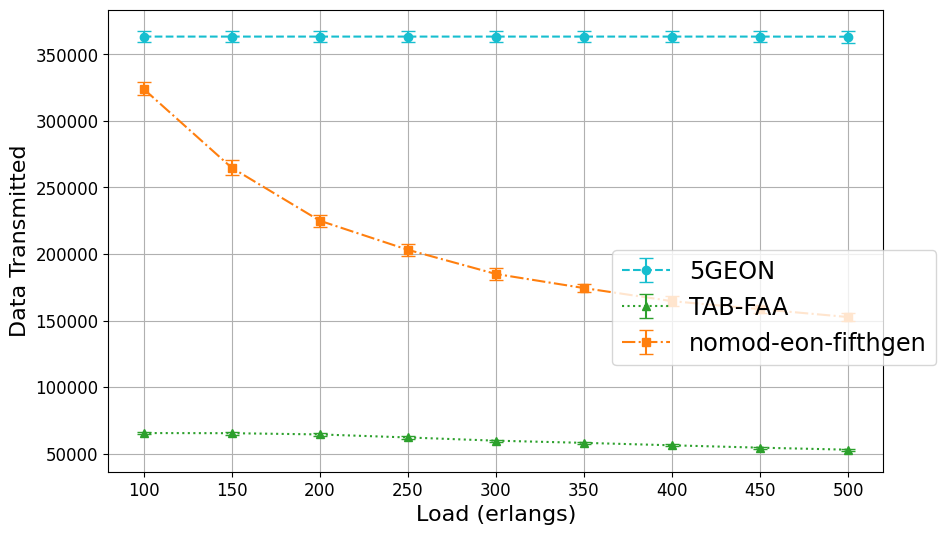

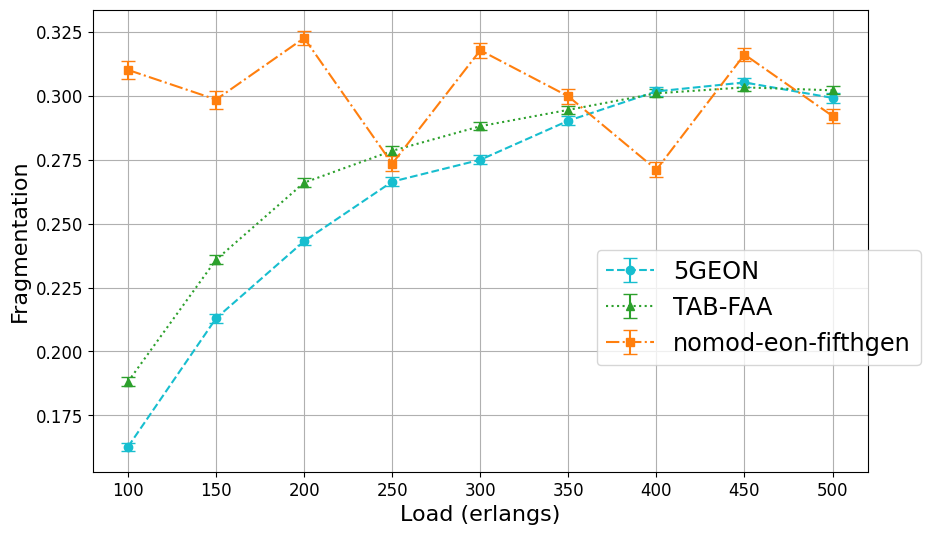

In [ ]:
# TODO It must defines all subplots in the figure to be at same height, so it'll be easier to compare.
# NOTE Now it's hardcoded, but it should be dynamic

algorithms = [
    'eon-fifthgen',
    'fifthgen',
    'nomod-eon-fifthgen'
    ]

metrics = [
    'avgbps',
    'ee',
    'hops',
    'jfi',
    'pc',
    'xtps',
    'mbbr',
    'data',
    'fragmentation'
    ]

height = [
    (0, 10),
    'ee',
    'hops',
    'jfi',
    'pc',
    'xtps',
    'mbbr',
    'data',
    'fragmentation'
    ]

names = [
    'Average Gbps',
    'Energy Efficiency',
    'Hops per Path',
    'JFI',
    'Power Consumption',
    'Crosstalk per Slot',
    'Blocking Bandwidth Ratio',
    'Data Transmitted',
    'Fragmentation'
    ]

# topologies = ['nsf', 'usa', 'pan', '5g']

data_folder = './data'
log = ['mbbr']

colors = [
    '#17becf', # cyan
    '#2ca02c', # green
    '#ff7f0e', # orange
    '#1f77b4', # blue
    '#d62728', # red
    '#9467bd', # purple
    '#e377c2', # magenta
]
ecolors = [
    '#17becf', # cyan
    '#2ca02c', # green
    '#ff7f0e', # orange
    '#1f77b4', # blue
    '#d62728', # red
    '#9467bd', # purple
    '#e377c2', # magenta
]

lines = ['dashed', 'dotted', 'dashdot']
markers = ['o', '^', 's']
# fmts = ['o--', 'o--', 'o--', 'o--']

ct = 0
for metric in metrics:
    # for topology in topologies:
    plt.figure(figsize=(10, 6))
    plt.rcParams.update({'font.size': 12})
    for algorithm in range(len(algorithms)):
        try:
            filename = f'{algorithms[algorithm]}-{metric}.dat'
            full_path = os.path.join(data_folder, filename)
            data = pd.read_csv(full_path, header=None, delimiter='\t')
            
            x = data[0]
            y = data[1]
            confidence_interval = data[2]

            # Name exchange
            if algorithms[algorithm] == 'fifthgen':
                name = 'TAB-FAA'
            elif algorithms[algorithm] == 'eon-fifthgen':
                name = '5GEON'
            elif algorithms[algorithm] == 'DC':
                name = 'Datacenter'
            else:
                name = algorithms[algorithm]

            # plt.errorbar(x, y, yerr=confidence_interval, fmt='o', color=colors[algorithm], ecolor=ecolors[algorithm], capsize=5, label=name)
            plt.errorbar(x, y, yerr=confidence_interval, marker=markers[algorithm], linestyle=lines[algorithm], color=colors[algorithm], ecolor=ecolors[algorithm], capsize=5, label=name)
            # plt.title(metric.upper(), fontsize=20)
            plt.ylabel(metric.capitalize(), fontsize=16)
            plt.ylabel(names[metrics.index(metric)], fontsize=16)
            if metric in log:
                plt.yscale('log')
        except:
            print('File not found.')


    if type(height[ct]) is tuple:
        plt.ylim(height[ct])
    else:
        plt.autoscale(enable=True, axis='y')

    ct += 1

    # Adding titles and labels
    # plt.legend(loc='center right', fontsize='x-large')
    plt.legend(loc=(0.65, 0.23), fontsize='x-large')
    # plt.ylim(10**-3, 1)
    plt.xlabel('Load (erlangs)', fontsize=16)

    # Customize X-axis to show the point clearly
    plt.xticks(x)

    # Show plot
    plt.grid(True)
    plt.savefig(f'./figures/{metric}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [27]:
# Markers for curves
# https://matplotlib.org/stable/api/markers_api.html

linestyle_str = [
     ('solid', 'solid'),      # Same as (0, ()) or '-'
     ('dotted', 'dotted'),    # Same as (0, (1, 1)) or ':'
     ('dashed', 'dashed'),    # Same as '--'
     ('dashdot', 'dashdot')]  # Same as '-.'

linestyle_tuple = [
     ('loosely dotted',        (0, (1, 10))),
     ('dotted',                (0, (1, 1))),
     ('densely dotted',        (0, (1, 1))),
     ('long dash with offset', (5, (10, 3))),
     ('loosely dashed',        (0, (5, 10))),
     ('dashed',                (0, (5, 5))),
     ('densely dashed',        (0, (5, 1))),

     ('loosely dashdotted',    (0, (3, 10, 1, 10))),
     ('dashdotted',            (0, (3, 5, 1, 5))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),

     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]

![alt text](sphx_glr_linestyles_001.webp)